# Explore blood dataset

Basic QC and UMAP visualization of `data/raw/blood_homo_sapiens.h5ad`
(200k cells, protein-coding genes, CZ CELLxGENE Census).

In [1]:
from pathlib import Path

import scanpy as sc

sc.settings.verbosity = 1
sc.settings.figdir = Path("figures")
sc.settings.figdir.mkdir(parents=True, exist_ok=True)

REPO_ROOT = Path("..").resolve()
DATA_PATH = REPO_ROOT / "data" / "raw" / "blood_homo_sapiens.h5ad"

In [2]:
adata = sc.read_h5ad(DATA_PATH)
adata

AnnData object with n_obs × n_vars = 200000 × 19512
    obs: 'assay', 'cell_type', 'tissue', 'tissue_general', 'disease', 'sex', 'suspension_type', 'donor_id'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'
    layers: None (.X)

## Overview

In [3]:
print(f"{adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"tissue: {adata.obs['tissue'].nunique()} unique")
print(f"donor_id (samples): {adata.obs['donor_id'].nunique()} unique")
print(f"cell_type: {adata.obs['cell_type'].nunique()} unique")
print(f"assay: {adata.obs['assay'].nunique()} unique")
print(f"disease: {adata.obs['disease'].nunique()} unique")

200,000 cells x 19,512 genes
tissue: 3 unique
donor_id (samples): 3151 unique
cell_type: 141 unique
assay: 18 unique
disease: 20 unique


In [4]:
adata.obs["tissue"].value_counts()

tissue
blood                   199635
umbilical cord blood       239
venous blood               126
Name: count, dtype: int64

In [5]:
adata.obs["assay"].value_counts()

assay
10x 3' v3                                          124849
10x 5' v2                                           23061
10x 3' v2                                           19696
10x 5' v1                                           15439
ScaleBio single cell RNA sequencing                  5319
10x 5' transcription profiling                       5162
10x 3' transcription profiling                       4981
Seq-Well                                              350
microwell-seq                                         341
particle-templated instant partition sequencing       178
HIVE CLX Single-Cell RNAseq Solution                  136
BD Rhapsody Whole Transcriptome Analysis              122
10x gene expression flex                              111
Parse Evercode Whole Transcriptome v2                  79
BD Rhapsody Targeted mRNA                              58
Asteria scRNA-seq kit                                  55
Smart-seq2                                             48
10x 3' v

In [6]:
adata.obs["disease"].value_counts()

disease
normal                                              106915
cytomegalovirus infection                            49548
COVID-19                                             28200
systemic lupus erythematosus                          6032
myelodysplastic syndrome                              1355
B-cell acute lymphoblastic leukemia                   1102
open-angle glaucoma                                   1075
myelodysplastic/myeloproliferative disease             974
hematologic disorder                                   769
respiratory system disorder                            747
post-COVID-19 disorder                                 732
juvenile dermatomyositis                               653
common variable immunodeficiency                       514
rheumatoid arthritis                                   390
clonal hematopoiesis                                   358
clear cell renal carcinoma                             261
influenza                                       

In [7]:
top_cell_types = adata.obs["cell_type"].value_counts().head(20)
top_cell_types

cell_type
naive thymus-derived CD4-positive, alpha-beta T cell    28189
CD14-positive, CD16-negative classical monocyte         18241
central memory CD4-positive, alpha-beta T cell          16129
effector memory CD8-positive, alpha-beta T cell         11670
CD16-positive, CD56-dim natural killer cell, human      10434
effector memory CD4-positive, alpha-beta T cell          9177
naive thymus-derived CD8-positive, alpha-beta T cell     8683
naive B cell                                             8169
CD4-positive, alpha-beta T cell                          7509
classical monocyte                                       7407
CD8-positive, alpha-beta T cell                          7192
B cell                                                   7106
natural killer cell                                      5717
CD14-positive monocyte                                   5166
memory B cell                                            3685
mucosal invariant T cell                                 368

## QC metrics

In [8]:
adata.var["mt"] = adata.var["feature_name"].str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

/tmp/ipykernel_758838/3605372594.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.violin(


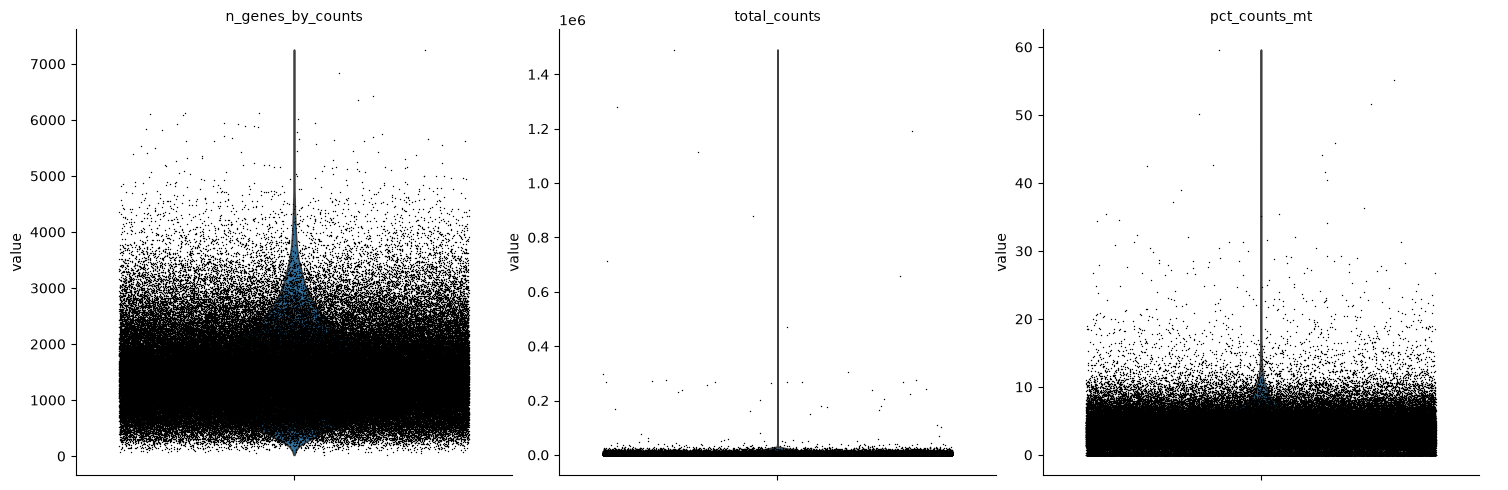

In [9]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_qc_violin.png",
)

## Preprocessing (normalize, HVGs, PCA)

In [10]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1106) > number of normalized dispersions (=279), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1327) > number of normalized dispersions (=1270), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1771) > number of normalized dispersions (=1397), returning all genes with normalized dispersions.
  objs_list = list(objs)
/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=2000) > number of normalized dispersions (=1953), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1485) > number of normalized dispersions (=1147), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1444) > number of normalized dispersions (=1368), returning all genes with normalized dispersions.
  objs_list = list(objs)


...

/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=2000) > number of normalized dispersions (=1968), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:417: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=273) > number of normalized dispersions (=10), returning all genes with normalized dispersions.
  objs_list = list(objs)
/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:417: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1623) > number of normalized dispersions (=296), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=2000) > number of normalized dispersions (=1335), returning all genes with normalized dispersions.
  objs_list = list(objs)
/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1901) > number of normalized dispersions (=712), returning all genes with normalized dispersions.
  objs_list = list(objs)


/home/bio/anaconda3/envs/sccontrast/lib/python3.12/site-packages/pandas/core/reshape/concat.py:504: UserWarning: `n_top_genes` (=1727) > number of normalized dispersions (=1088), returning all genes with normalized dispersions.
  objs_list = list(objs)


/tmp/ipykernel_758838/3334721059.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.highly_variable_genes(adata, save="_hvg.png")


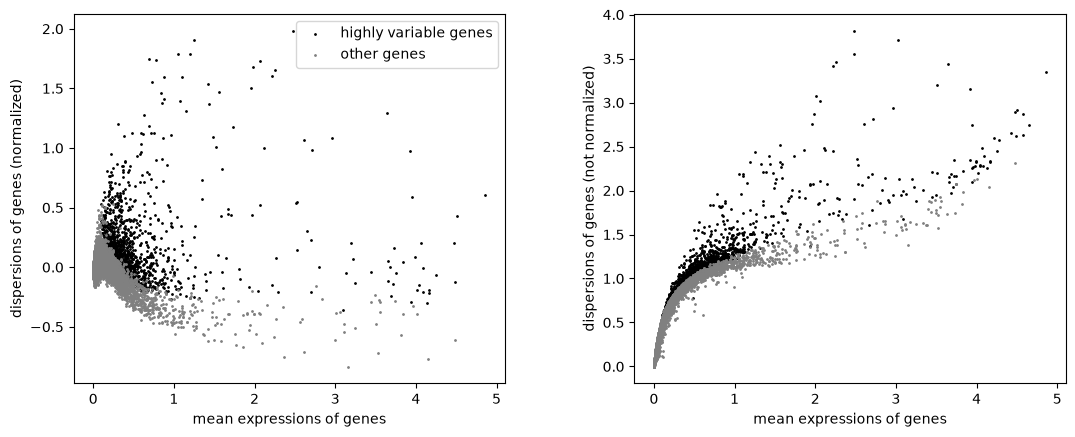

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")
sc.pl.highly_variable_genes(adata, save="_hvg.png")

/home/bio/anaconda3/envs/sccontrast/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


/tmp/ipykernel_758838/3602808478.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, save="_pca_variance.png")


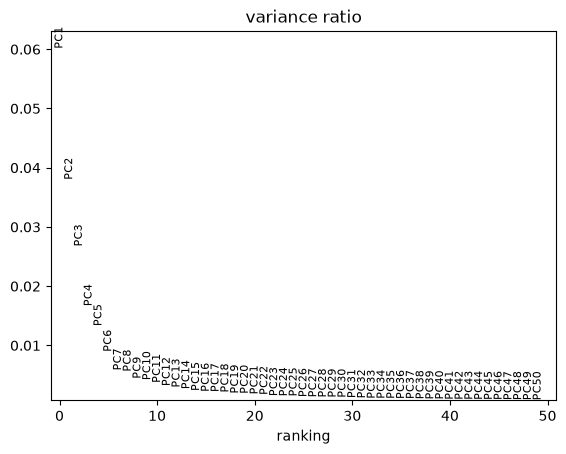

In [12]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=50, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, save="_pca_variance.png")

## Neighbors + UMAP

In [13]:
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg)

# carry embeddings back onto full adata for plotting with all obs columns
adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"]

## UMAP plots

In [14]:
top20_types = adata.obs["cell_type"].value_counts().head(20).index
cell_type_top20 = adata.obs["cell_type"].astype(str)
cell_type_top20[~cell_type_top20.isin(top20_types)] = "other"
adata.obs["cell_type_top20"] = cell_type_top20.astype("category")

/tmp/ipykernel_758838/3509323653.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


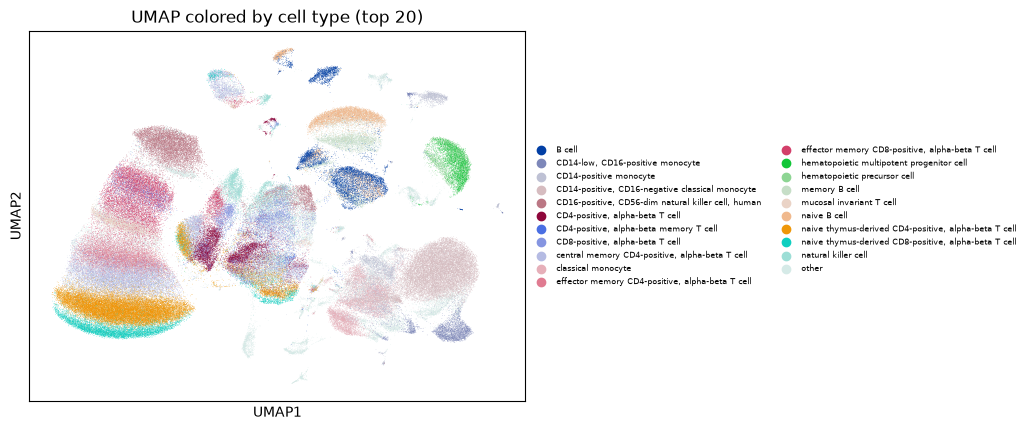

In [15]:
sc.pl.umap(
    adata,
    color="cell_type_top20",
    legend_loc="right margin",
    legend_fontsize=6,
    title="UMAP colored by cell type (top 20)",
    save="_cell_type.png",
)

/tmp/ipykernel_758838/3850271819.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


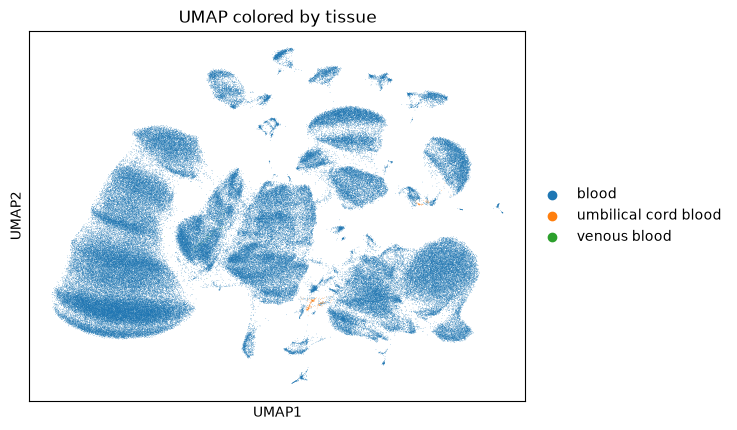

In [16]:
sc.pl.umap(
    adata,
    color="tissue",
    title="UMAP colored by tissue",
    save="_tissue.png",
)

/tmp/ipykernel_758838/1562883941.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


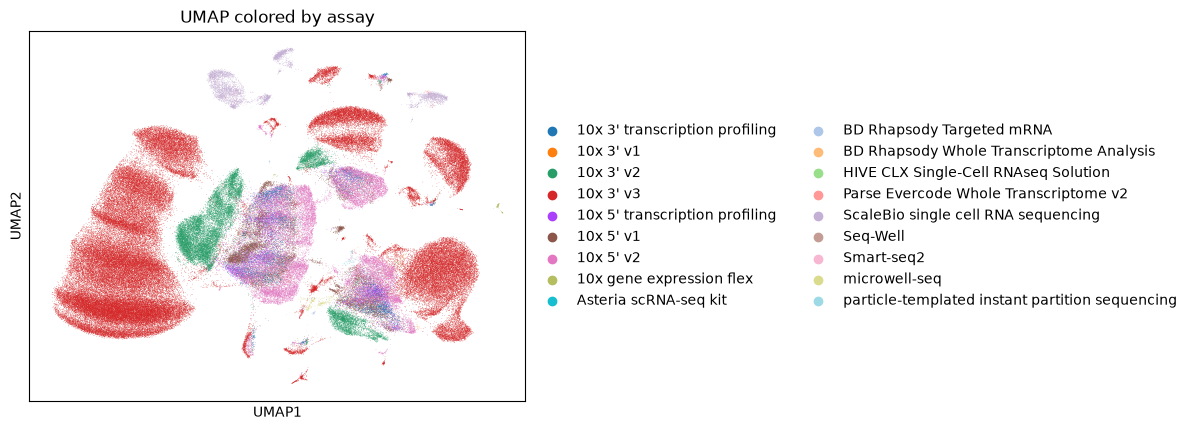

In [17]:
sc.pl.umap(
    adata,
    color="assay",
    title="UMAP colored by assay",
    save="_assay.png",
)

/tmp/ipykernel_758838/4153218699.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


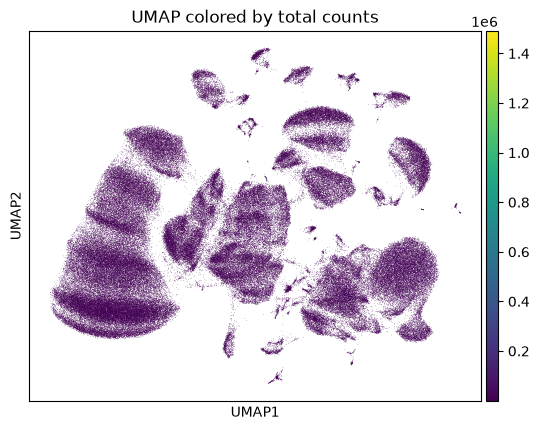

In [18]:
sc.pl.umap(
    adata,
    color="total_counts",
    title="UMAP colored by total counts",
    save="_total_counts.png",
)

## Donor / sample composition

In [19]:
cells_per_donor = adata.obs["donor_id"].value_counts()
cells_per_donor.describe()

count    3151.000000
mean       63.471914
std       217.636919
min         1.000000
25%        10.000000
50%        17.000000
75%        38.000000
max      5258.000000
Name: count, dtype: float64

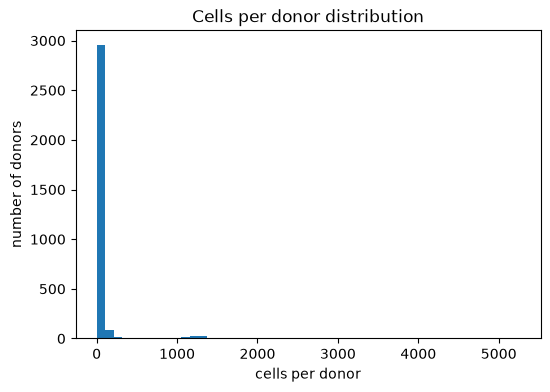

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(cells_per_donor.values, bins=50)
ax.set_xlabel("cells per donor")
ax.set_ylabel("number of donors")
ax.set_title("Cells per donor distribution")
fig.savefig(sc.settings.figdir / "cells_per_donor_hist.png", dpi=150, bbox_inches="tight")
plt.show()